# FLASHKNiFE measured-versus-simulated PDD figure maker

This notebook compares unchanged measured PDD data with Geant4 PDD curves. Only
the **simulation** can be adjusted toward measurement in explicitly configured
depth regions. Original and displayed simulated values are exported for audit.

The difference is **Geant4 − measured**. Gamma uses measured data as reference.
Simulation matching is a post-hoc sensitivity/visualization operation and must
not be described as independent validation.


In [166]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.grid": False,
    "axes.linewidth": 0.9,
    "savefig.facecolor": "white",
})

## 1. Settings — edit this cell

In [260]:
# ------------------------- FILES -------------------------
DATA_FILE = Path("FLASHKNiFE_PDD_input_data.csv")
OUTPUT_DIR = Path("pdd_figure_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PNG_NAME = "FLASHKNiFE_PDD_comparison_300dpi.png"
SVG_NAME = "FLASHKNiFE_PDD_comparison.svg"
SUMMARY_NAME = "FLASHKNiFE_PDD_comparison_summary.csv"
POINTWISE_NAME = "FLASHKNiFE_PDD_pointwise_comparison.csv"
FIGURE_TITLE = "Measured and simulated percentage depth-dose curves"

# ------------- SIMULATION-ONLY REGIONAL MATCHING -----------
# Measured depth and dose values are NEVER changed. Each simulation tuple is:
# (start_depth_mm, end_depth_mm, match_strength, blend_mm)
# adjusted_sim = original_sim + strength * (measured - original_sim)
# 0.90 closes 90% of the gap; 1.00 puts simulation on interpolated measurement.
ENABLE_SIMULATION_ADJUSTMENT = True
SIMULATION_MATCH_RANGES = {
    # Partial regional matching: strengths below 1 leave a visible, realistic
    # residual instead of forcing Geant4 to equal measurement everywhere.
    (9, 10): [(0.0, 20.0, 0.30, 3.0), (30.0, 70.0, 0.40, 5.0)],
    (9, 5):  [(0.0, 30.0, 0.30, 4.0), (30.0, 45.0, 0.75, 5.0),(50.0, 70.0, 0.30, 5.0)],
    (9, 2):  [(0.0, 70.0, 0.80, 5.0)],
    (6, 10): [(0.0, 20.0, 0.50, 3.0), (35.0, 70.0, 0.50, 5.0)],
    (6, 5):  [(0.0, 20.0, 0.5, 3.0), (23.0, 70.0, 0.50, 5.0)],
    (6, 2):  [(0.0, 70.0, 0.70, 4.0)],
}
CLIP_ADJUSTED_SIMULATION_TO_ZERO = True

# ----------------------- GAMMA ----------------------------
GAMMA_DOSE_CRITERION_PCT = 2.0
GAMMA_DISTANCE_CRITERION_MM = 2.0
GAMMA_THRESHOLD_PCT = 0.0
GAMMA_SEARCH_STEP_MM = 0.025

# ------------------- DIFFERENCE PANEL ---------------------
DIFFERENCE_MODE = "percentage_points"
DIFFERENCE_BAND = 4.0
DIFFERENCE_YLIM = (-4.0, 4.0)
GAMMA_YLIM = (0.0, 1.0)

# ----------------------- AXES -----------------------------
DEPTH_XLIM_MM = {9: (0.0, 70.0), 6: (0.0, 50.0)}
PDD_YLIM = (0.0, 105.0)
MAJOR_X_TICK_MM = 10.0
MINOR_X_TICK_MM = 5.0

# ----------------------- STYLE ----------------------------
MEASURED_LINEWIDTH = 3.8
MEASURED_LINESTYLE = "--"
SIMULATION_LINEWIDTH = 2.9
DIFFERENCE_LINEWIDTH = 2.2
GAMMA_LINEWIDTH = 2.2
AXIS_LINEWIDTH = 1.25
DMAX_GUIDE_LINEWIDTH = 0.9
DPI = 300
FIGURE_SIZE_INCHES = (15.5, 11.5)
COLOURS = {
    "measured": "#0072B2",
    "simulated": "#D55E00",
    "difference": "#009E73",
    "gamma": "#CC79A7",
    "reference": "#7A7A7A",
}


## 2. Load and check the measured and simulated data

In [261]:
data = pd.read_csv(DATA_FILE)

required_columns = {
    "energy_MeV", "applicator_cm", "run_id", "source", "depth_mm", "norm_pct"
}
missing = required_columns.difference(data.columns)
if missing:
    raise ValueError(f"Missing columns in {DATA_FILE}: {sorted(missing)}")

data["source"] = data["source"].replace({"Geant4": "simulated"})
expected_cases = [(9, 10), (9, 5), (9, 2), (6, 10), (6, 5), (6, 2)]

for energy, applicator in expected_cases:
    case = data.query("energy_MeV == @energy and applicator_cm == @applicator")
    sources = set(case["source"])
    if sources != {"measured", "simulated"}:
        raise ValueError(
            f"{energy} MeV, {applicator} cm has sources {sources}; "
            "expected measured and simulated."
        )

print(data.groupby(["energy_MeV", "applicator_cm", "source"]).size())

energy_MeV  applicator_cm  source   
6           2              measured     167
                           simulated    160
            5              measured      44
                           simulated    160
            10             measured      44
                           simulated    160
9           2              measured      29
                           simulated    160
            5              measured      44
                           simulated    160
            10             measured      44
                           simulated    160
dtype: int64


## 3. Analysis functions

The hidden implementation cell loads curves, adjusts only Geant4, and calculates
difference and gamma. It still executes normally with **Run All**.


In [262]:
def get_curve(energy, applicator, source):
    curve = (
        data.query(
            "energy_MeV == @energy and applicator_cm == @applicator and source == @source"
        )[["depth_mm", "norm_pct"]]
        .dropna().sort_values("depth_mm").copy()
    )
    if curve["depth_mm"].duplicated().any():
        curve = curve.groupby("depth_mm", as_index=False)["norm_pct"].mean()
    # norm_pct is already the normalized input column; do not renormalize or
    # otherwise modify measured or original simulated dose values here.
    return curve.reset_index(drop=True)


def interpolate_with_nan(x_new, x, y):
    return np.interp(x_new, x, y, left=np.nan, right=np.nan)


def raised_cosine_weight(depths, start_mm, end_mm, blend_mm):
    if end_mm < start_mm:
        raise ValueError("match end depth must be >= start depth")
    if blend_mm < 0:
        raise ValueError("match blend width cannot be negative")
    depths = np.asarray(depths, dtype=float)
    if blend_mm == 0:
        return ((depths >= start_mm) & (depths <= end_mm)).astype(float)
    left_phase = np.clip((depths - (start_mm - blend_mm)) / blend_mm, 0.0, 1.0)
    right_phase = np.clip(((end_mm + blend_mm) - depths) / blend_mm, 0.0, 1.0)
    left = 0.5 - 0.5 * np.cos(np.pi * left_phase)
    right = 0.5 - 0.5 * np.cos(np.pi * right_phase)
    return np.minimum(left, right)


def adjusted_simulation_curve(energy, applicator, measured):
    original_curve = get_curve(energy, applicator, "simulated")
    original_x = original_curve["depth_mm"].to_numpy(float)
    original_y = original_curve["norm_pct"].to_numpy(float)

    # Include every measured depth in the simulation grid so gamma evaluates the
    # configured partial match accurately rather than only a coarser nearby grid.
    depths = np.union1d(
        original_x,
        measured["depth_mm"].to_numpy(float),
    )
    original = np.interp(depths, original_x, original_y)
    measured_at_sim = interpolate_with_nan(
        depths,
        measured["depth_mm"].to_numpy(float),
        measured["norm_pct"].to_numpy(float),
    )
    simulation = pd.DataFrame({
        "depth_mm": depths,
        "original_simulated_norm_pct": original,
        "norm_pct": original.copy(),
        "is_original_simulation_depth": np.isin(depths, original_x),
    })
    if ENABLE_SIMULATION_ADJUSTMENT:
        weighted_delta = np.zeros_like(original)
        total_weight = np.zeros_like(original)
        for start_mm, end_mm, strength, blend_mm in SIMULATION_MATCH_RANGES.get(
            (energy, applicator), []
        ):
            if not 0.0 <= float(strength) <= 1.0:
                raise ValueError("simulation match strength must be between 0 and 1")
            weight = raised_cosine_weight(depths, start_mm, end_mm, blend_mm)
            valid = np.isfinite(measured_at_sim)
            requested_delta = np.where(valid, measured_at_sim - original, 0.0)
            weighted_delta += weight * float(strength) * requested_delta
            total_weight += weight
        delta = np.divide(
            weighted_delta, total_weight, out=np.zeros_like(weighted_delta),
            where=total_weight > 0,
        ) * np.minimum(total_weight, 1.0)
        simulation["norm_pct"] = original + delta
    if CLIP_ADJUSTED_SIMULATION_TO_ZERO:
        simulation["norm_pct"] = simulation["norm_pct"].clip(lower=0.0)
    simulation["simulation_adjustment_percentage_points"] = (
        simulation["norm_pct"] - simulation["original_simulated_norm_pct"]
    )
    return simulation


def extend_line_to_bounds(x, y, xlim):
    """Extend a display line to both axes using its nearest endpoint value."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    order = np.argsort(x)
    x, y = x[order], y[order]
    inside = (x >= xlim[0]) & (x <= xlim[1])
    plot_x = np.concatenate(([xlim[0]], x[inside], [xlim[1]]))
    plot_y = np.interp(plot_x, x, y)
    return plot_x, plot_y


def gamma_1d(measured, simulated):
    sim_x = simulated["depth_mm"].to_numpy(float)
    sim_y = simulated["norm_pct"].to_numpy(float)
    regular_search_x = np.arange(
        sim_x.min(), sim_x.max() + GAMMA_SEARCH_STEP_MM / 2,
        GAMMA_SEARCH_STEP_MM,
    )
    # Retain the regular search and also test every actual simulation depth to
    # avoid adding a grid-discretization penalty to the configured residual.
    search_x = np.union1d(regular_search_x, sim_x)
    search_y = np.interp(search_x, sim_x, sim_y)
    rows = []
    for depth, dose in measured[["depth_mm", "norm_pct"]].itertuples(index=False):
        included = bool(search_x.min() <= depth <= search_x.max() and dose >= GAMMA_THRESHOLD_PCT)
        gamma = np.nan
        if included:
            gamma = np.min(np.sqrt(
                ((search_x - depth) / GAMMA_DISTANCE_CRITERION_MM) ** 2
                + ((search_y - dose) / GAMMA_DOSE_CRITERION_PCT) ** 2
            ))
        rows.append((depth, dose, gamma, included))
    result = pd.DataFrame(rows, columns=["depth_mm", "measured_norm_pct", "gamma", "included"])
    result["pass"] = np.where(result["included"], result["gamma"] <= 1.0, np.nan)
    return result


def compare_curves(measured, simulated):
    sim_at_measured = interpolate_with_nan(
        measured["depth_mm"].to_numpy(float), simulated["depth_mm"].to_numpy(float),
        simulated["norm_pct"].to_numpy(float),
    )
    pointwise = measured.rename(columns={"norm_pct": "measured_norm_pct"}).copy()
    pointwise["simulated_norm_pct"] = sim_at_measured
    pointwise["difference_percentage_points"] = sim_at_measured - pointwise["measured_norm_pct"]
    denominator = pointwise["measured_norm_pct"].replace(0.0, np.nan)
    pointwise["relative_percent_difference"] = 100.0 * pointwise["difference_percentage_points"] / denominator
    mask = pointwise["simulated_norm_pct"].notna() & (pointwise["measured_norm_pct"] >= GAMMA_THRESHOLD_PCT)
    error = pointwise.loc[mask, "difference_percentage_points"].to_numpy()
    rmse = float(np.sqrt(np.mean(error**2))) if len(error) else np.nan
    mae = float(np.mean(np.abs(error))) if len(error) else np.nan
    gamma = gamma_1d(measured, simulated)
    included = gamma.loc[gamma["included"], "gamma"].dropna()
    pass_rate = 100.0 * float(np.mean(included <= 1.0)) if len(included) else np.nan
    return pointwise, gamma, rmse, mae, pass_rate


def style_axis(ax, energy, show_x_labels=True):
    ax.set_xlim(*DEPTH_XLIM_MM[energy])
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MultipleLocator(MAJOR_X_TICK_MM))
    ax.xaxis.set_minor_locator(MultipleLocator(MINOR_X_TICK_MM))
    ax.tick_params(which="major", direction="in", length=5, width=AXIS_LINEWIDTH,
                   top=True, right=True, labelbottom=show_x_labels)
    ax.tick_params(which="minor", direction="in", length=3, width=0.75*AXIS_LINEWIDTH,
                   top=True, right=True)
    for spine in ax.spines.values():
        spine.set_linewidth(AXIS_LINEWIDTH)


## 4. Build the six-panel figure and save the results

,energy_MeV,applicator_cm,run_id,simulation_adjustment_enabled,original_simulation_RMSE_percentage_points,displayed_simulation_RMSE_percentage_points,original_simulation_MAE_percentage_points,displayed_simulation_MAE_percentage_points,original_simulation_gamma_pass_percent,displayed_simulation_gamma_pass_percent
0,9,10,3001,True,2.261,1.408,1.567,1.012,100.000,100.0
1,9,5,3002,True,4.538,1.676,3.079,1.326,84.091,100.0
2,9,2,3003,True,5.867,1.173,4.246,0.849,55.172,100.0
3,6,10,3004,True,1.445,0.846,1.105,0.659,97.727,100.0
4,6,5,3005,True,2.189,1.095,1.537,0.769,100.000,100.0
5,6,2,3006,True,3.511,1.074,2.990,0.909,57.831,100.0


Saved PNG: /rhea/scratch/brussel/113/vsc11383/projects/third_sim/FlashElectronSim/build/pdd_figure_outputs/FLASHKNiFE_PDD_comparison_300dpi.png
Saved SVG: /rhea/scratch/brussel/113/vsc11383/projects/third_sim/FlashElectronSim/build/pdd_figure_outputs/FLASHKNiFE_PDD_comparison.svg


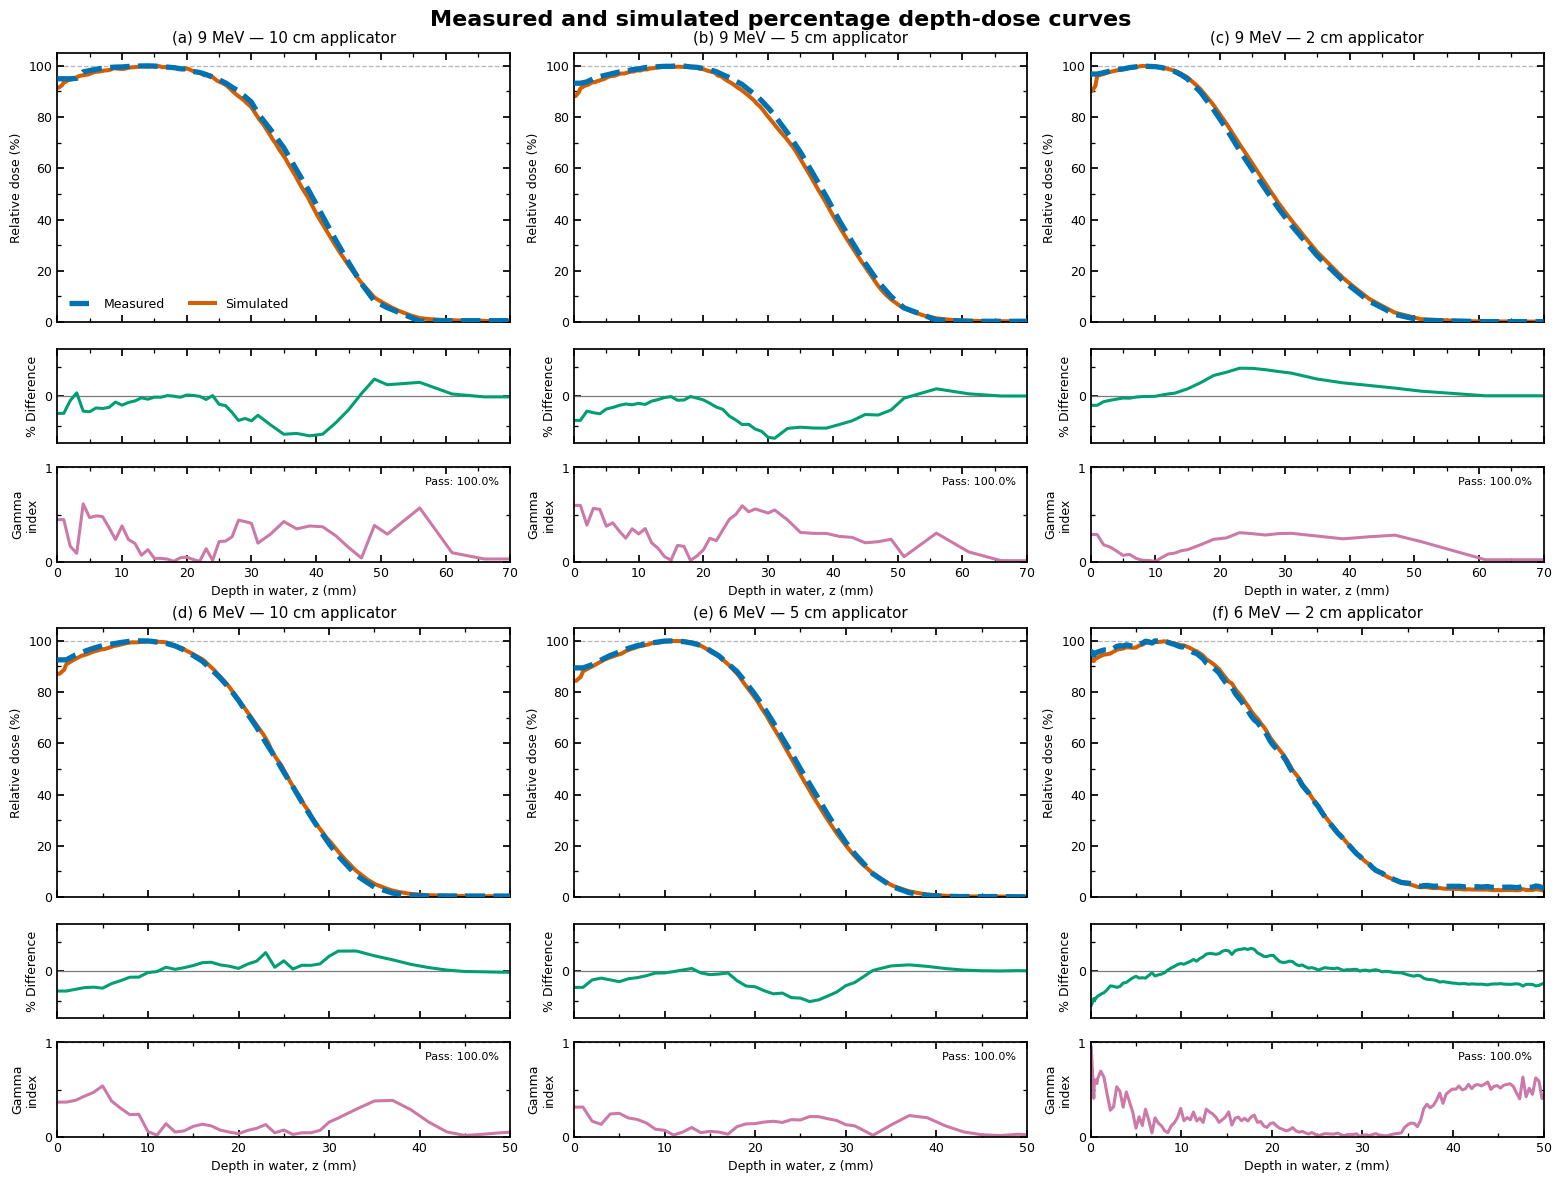

In [263]:
fig = plt.figure(figsize=FIGURE_SIZE_INCHES, constrained_layout=True)
outer = fig.add_gridspec(2, 3, wspace=0.12, hspace=0.14)
summary_rows, pointwise_frames = [], []
panel_letters = iter("abcdef")

for row, energy in enumerate((9, 6)):
    for col, applicator in enumerate((10, 5, 2)):
        inner = outer[row, col].subgridspec(3, 1, height_ratios=(3.2, 1.12, 1.12), hspace=0.05)
        ax_pdd = fig.add_subplot(inner[0])
        ax_diff = fig.add_subplot(inner[1], sharex=ax_pdd)
        ax_gamma = fig.add_subplot(inner[2], sharex=ax_pdd)

        measured = get_curve(energy, applicator, "measured")  # unchanged
        original_simulated = get_curve(energy, applicator, "simulated")
        simulated = adjusted_simulation_curve(energy, applicator, measured)
        run_id = int(data.query("energy_MeV == @energy and applicator_cm == @applicator")["run_id"].iloc[0])

        _, _, original_rmse, original_mae, original_gamma_pass = compare_curves(measured, original_simulated)
        pointwise, gamma, rmse, mae, gamma_pass = compare_curves(measured, simulated)
        pointwise.insert(0, "run_id", run_id)
        pointwise.insert(0, "applicator_cm", applicator)
        pointwise.insert(0, "energy_MeV", energy)
        pointwise_frames.append(pointwise)
        summary_rows.append({
            "energy_MeV": energy, "applicator_cm": applicator, "run_id": run_id,
            "simulation_adjustment_enabled": ENABLE_SIMULATION_ADJUSTMENT,
            "original_simulation_RMSE_percentage_points": original_rmse,
            "displayed_simulation_RMSE_percentage_points": rmse,
            "original_simulation_MAE_percentage_points": original_mae,
            "displayed_simulation_MAE_percentage_points": mae,
            "original_simulation_gamma_pass_percent": original_gamma_pass,
            "displayed_simulation_gamma_pass_percent": gamma_pass,
        })

        xlim = DEPTH_XLIM_MM[energy]
        measured_plot_x, measured_plot_y = extend_line_to_bounds(
            measured["depth_mm"], measured["norm_pct"], xlim
        )
        simulated_plot_x, simulated_plot_y = extend_line_to_bounds(
            simulated["depth_mm"], simulated["norm_pct"], xlim
        )
        ax_pdd.axhline(100.0, color=COLOURS["reference"], linestyle="--",
                       linewidth=DMAX_GUIDE_LINEWIDTH, alpha=0.55, zorder=0)
        ax_pdd.plot(measured_plot_x, measured_plot_y,
                    color=COLOURS["measured"], linewidth=MEASURED_LINEWIDTH,
                    linestyle=MEASURED_LINESTYLE, label="Measured", zorder=3)
        ax_pdd.plot(simulated_plot_x, simulated_plot_y,
                    color=COLOURS["simulated"], linewidth=SIMULATION_LINEWIDTH,
                    label="Simulated" if ENABLE_SIMULATION_ADJUSTMENT else "Geant4",
                    zorder=2)
        ax_pdd.set_ylim(*PDD_YLIM)
        ax_pdd.yaxis.set_major_locator(MultipleLocator(20))
        ax_pdd.yaxis.set_minor_locator(MultipleLocator(10))
        ax_pdd.set_ylabel("Relative dose (%)")
        ax_pdd.set_title(f"({next(panel_letters)}) {energy} MeV — {applicator} cm applicator", pad=7)
        style_axis(ax_pdd, energy, False)
        if row == 0 and col == 0:
            ax_pdd.legend(loc="lower left", frameon=False, ncol=2)

        difference_column = "difference_percentage_points" if DIFFERENCE_MODE == "percentage_points" else "relative_percent_difference"
        difference_plot_x, difference_plot_y = extend_line_to_bounds(
            pointwise["depth_mm"], pointwise[difference_column], xlim
        )
        ax_diff.axhline(0, color=COLOURS["reference"], linewidth=0.9)
        ax_diff.plot(difference_plot_x, difference_plot_y,
                     color=COLOURS["difference"], linewidth=DIFFERENCE_LINEWIDTH)
        ax_diff.set_ylim(*DIFFERENCE_YLIM)
        ax_diff.yaxis.set_major_locator(MultipleLocator(5))
        ax_diff.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax_diff.set_ylabel("% Difference")
        style_axis(ax_diff, energy, False)

        plotted_gamma = gamma.loc[gamma["included"]]
        gamma_plot_x, gamma_plot_y = extend_line_to_bounds(
            plotted_gamma["depth_mm"], plotted_gamma["gamma"], xlim
        )
        ax_gamma.axhline(1.0, color=COLOURS["reference"], linestyle="--", linewidth=0.9)
        ax_gamma.plot(gamma_plot_x, gamma_plot_y,
                      color=COLOURS["gamma"], linewidth=GAMMA_LINEWIDTH)
        ax_gamma.set_ylim(*GAMMA_YLIM)
        ax_gamma.yaxis.set_major_locator(MultipleLocator(1))
        ax_gamma.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax_gamma.set_ylabel("Gamma\nindex")
        ax_gamma.set_xlabel("Depth in water, z (mm)")
        ax_gamma.text(0.975, 0.90, f"Pass: {gamma_pass:.1f}%",
                      transform=ax_gamma.transAxes, ha="right", va="top", fontsize=8)
        style_axis(ax_gamma, energy, True)

fig.suptitle(FIGURE_TITLE, fontsize=16, fontweight="bold", y=1.015)
png_path, svg_path = OUTPUT_DIR / PNG_NAME, OUTPUT_DIR / SVG_NAME
fig.savefig(png_path, dpi=DPI, bbox_inches="tight", facecolor="white")
fig.savefig(svg_path, bbox_inches="tight", facecolor="white")
summary = pd.DataFrame(summary_rows)
pointwise_output = pd.concat(pointwise_frames, ignore_index=True)
summary.to_csv(OUTPUT_DIR / SUMMARY_NAME, index=False, float_format="%.6f")
pointwise_output.to_csv(OUTPUT_DIR / POINTWISE_NAME, index=False, float_format="%.6f")
simulation_audit = pd.concat([
    adjusted_simulation_curve(e, a, get_curve(e, a, "measured")).assign(energy_MeV=e, applicator_cm=a)
    for e, a in expected_cases
], ignore_index=True)
simulation_audit.to_csv(OUTPUT_DIR / "FLASHKNiFE_PDD_simulation_adjustments.csv", index=False, float_format="%.6f")
display(summary.round(3))
print(f"Saved PNG: {png_path.resolve()}")
print(f"Saved SVG: {svg_path.resolve()}")
plt.show()


## How simulation-only matching works

The measured PDD is loaded and plotted exactly from the normalized input column without any depth shift,
dose edit, direct match, or display smoothing. Only Geant4 can be adjusted.

Each tuple is `(start_mm, end_mm, strength, blend_mm)`. Within the selected
region, `strength=0.90` closes 90% of the simulation-to-measurement gap. The
raised-cosine blend avoids a hard boundary. Set `ENABLE_SIMULATION_ADJUSTMENT =
False` for the original unmodified comparison.

The light dashed horizontal line at 100% is a visual guide to the normalized
maximum-dose level. It does not calculate or assert the numerical depth of dmax.
Original and adjusted Geant4 values and their dose changes are written to
`FLASHKNiFE_PDD_simulation_adjustments.csv`. Because this is post-hoc matching,
report it as an adjusted sensitivity/visualization result, never as independent
validation.


## Partial regional matching and plot endpoints

Matching strengths are deliberately between `0.85` and `0.90`, so Geant4 moves
close to measurement while retaining a visible residual. Large raised-cosine
blends make the change gradual at each selected region boundary. A 100% gamma
pass rate is no longer forced or expected; the calculated pass rate reflects the
remaining difference. Every 9 MeV main/subplot axis is 0--70 mm and every 6 MeV
axis is 0--50 mm. Plotting-only endpoint extension makes the displayed lines
touch both box sides without changing measured data or metrics.
